<a href="https://colab.research.google.com/github/leesasang/codein_study/blob/main/%EC%9D%B4%EC%B1%84%EC%97%B0_%EA%B0%9C%EC%9D%B8%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B84_%EC%B5%9C%EC%A2%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 데이터 처리용 라이브러리
import pandas as pd
import numpy as np

# 그래프 시각화 라이브러리
import matplotlib.pyplot as plt

# 파일 및 폴더 관리
import os
import zipfile

# 선형 회귀 모델
from sklearn.linear_model import LinearRegression

In [2]:
# zip 파일 경로 지정
zip_path = "/content/I-V_curves_raw_data.zip"

# 압축 해제
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/iv_data")

In [3]:
# 압축 해제된 파일 목록 확인
os.listdir("/content/iv_data")

['I-V_1250Wm-2.txt',
 'I-V_1125Wm-2.txt',
 'I-V_625Wm-2.txt',
 'I-V_250Wm-2.txt',
 'I-V_500Wm-2.txt',
 'I-V_1000Wm-2.txt',
 'I-V_1500Wm-2.txt',
 'I-V_1375Wm-2.txt',
 'I-V_750Wm-2.txt',
 'I-V_375Wm-2.txt',
 'I-V_875Wm-2.txt']

In [4]:
# 사용할 데이터 파일 선택
sample_file = "/content/iv_data/I-V_375Wm-2.txt"

# txt 파일 읽기
df = pd.read_csv(
    sample_file,
    sep='\t',        # 탭 기준 분리
    skiprows=1,      # 첫 줄 제거
    names=['V','I']  # 컬럼 이름 지정
)

# 데이터 확인
df.head()

,V,I
0,-12.855646,3.638949
1,-12.673679,3.638949
2,-12.461384,3.681427
3,-12.264252,3.638949
4,-12.036793,3.653109


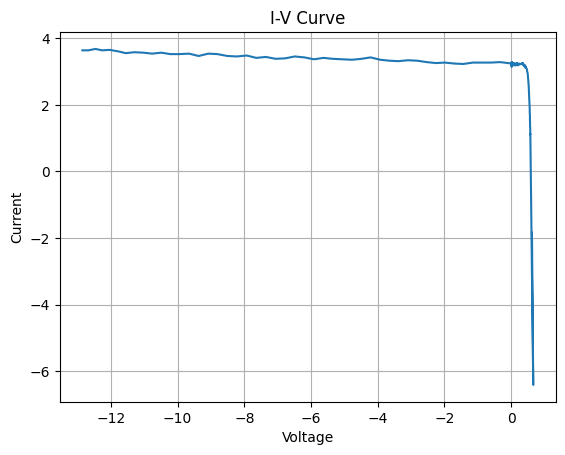

In [5]:
# I-V 곡선 그래프 출력
plt.plot(df['V'], df['I'])

# 그래프 축 이름
plt.xlabel("Voltage")
plt.ylabel("Current")

# 그래프 제목
plt.title("I-V Curve")

# 격자 표시
plt.grid()

# 그래프 출력
plt.show()

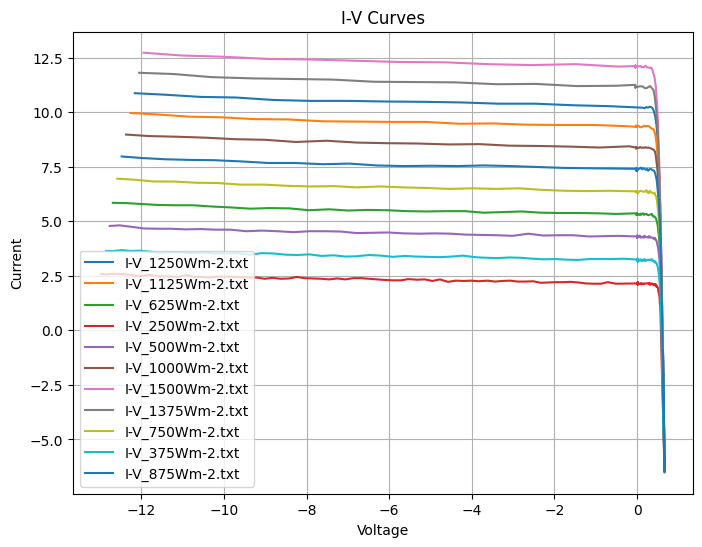

In [6]:
# 데이터 폴더 경로
folder = "/content/iv_data"

# 그래프 크기 설정
plt.figure(figsize=(8,6))

# 폴더 내 모든 txt 파일 반복
for file in os.listdir(folder):

    # txt 파일만 선택
    if file.endswith(".txt"):

        path = os.path.join(folder, file)

        # 데이터 읽기
        df = pd.read_csv(
            path,
            sep='\t',
            skiprows=1,
            names=['V','I']
        )

        # 그래프 추가
        plt.plot(df['V'], df['I'], label=file)

# 그래프 설정
plt.xlabel("Voltage")
plt.ylabel("Current")
plt.title("I-V Curves")

# 범례 표시
plt.legend()

# 격자 표시
plt.grid()

# 그래프 출력
plt.show()

In [10]:
# 정상 데이터 불러오기
df = pd.read_csv(
    "/content/iv_data/I-V_375Wm-2.txt",
    sep='\t',
    skiprows=1,
    names=['V','I']
)

# 노이즈 데이터 생성
noise_df = df.copy()

# 랜덤 노이즈 추가
noise_df['I'] = (
    noise_df['I']
    + np.random.normal(0, 0.2, len(noise_df))
)

# 출력 저하 데이터 생성
degraded_df = df.copy()

# 전류값 감소
degraded_df['I'] = degraded_df['I'] * 0.7

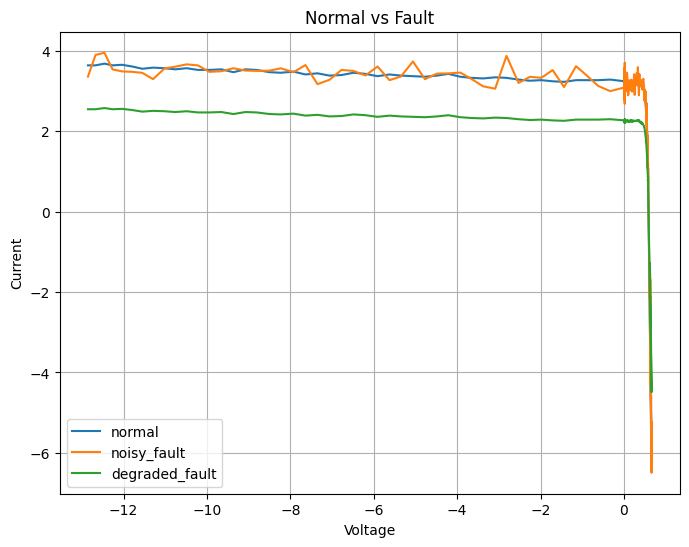

In [11]:
# 그래프 크기 설정
plt.figure(figsize=(8,6))

# 정상 데이터
plt.plot(df['V'], df['I'], label='normal')

# 노이즈 데이터
plt.plot(
    noise_df['V'],
    noise_df['I'],
    label='noisy_fault'
)

# 성능 저하 데이터
plt.plot(
    degraded_df['V'],
    degraded_df['I'],
    label='degraded_fault'
)

# 그래프 설정
plt.xlabel("Voltage")
plt.ylabel("Current")
plt.title("Normal vs Fault")

# 범례 표시
plt.legend()

# 격자 표시
plt.grid()

# 그래프 출력
plt.show()

In [17]:
print("===== 상태 분석 결과 =====")

# 1. 정상 데이터

normal_noise = np.std(df['I'])

if normal_noise < 5:
    print("정상 데이터: NORMAL")

else:
    print("정상 데이터: FAULT")


# 2. 노이즈 데이터

noise = np.std(
    noise_df['I'] - df['I']
)

if noise > 0.15:
    print("노이즈 데이터: FAULT")

else:
    print("노이즈 데이터: NORMAL")


# 3. 출력 저하 데이터

degraded_mean = np.mean(degraded_df['I'])
normal_mean = np.mean(df['I'])

if degraded_mean < normal_mean * 0.8:
    print("출력 저하 데이터: FAULT")

else:
    print("출력 저하 데이터: NORMAL")

===== 상태 분석 결과 =====
정상 데이터: NORMAL
노이즈 데이터: FAULT
출력 저하 데이터: FAULT


In [15]:
# feature 값 계산

normal_mean = np.mean(df['I'])
noise_mean = np.mean(noise_df['I'])
degraded_mean = np.mean(degraded_df['I'])

normal_noise = np.std(df['I'])
noise_value = np.std(noise_df['I'])
degraded_noise = np.std(degraded_df['I'])

# 표 생성
result_df = pd.DataFrame({

    'State': [
        'normal',
        'noisy_fault',
        'degraded_fault'
    ],

    'Mean Current': [
        normal_mean,
        noise_mean,
        degraded_mean
    ],

    'Noise': [
        normal_noise,
        noise_value,
        degraded_noise
    ]
})

# 출력
print(result_df)

            State  Mean Current     Noise
0          normal      0.593721  3.318783
1     noisy_fault      0.609566  3.310056
2  degraded_fault      0.415605  2.323148


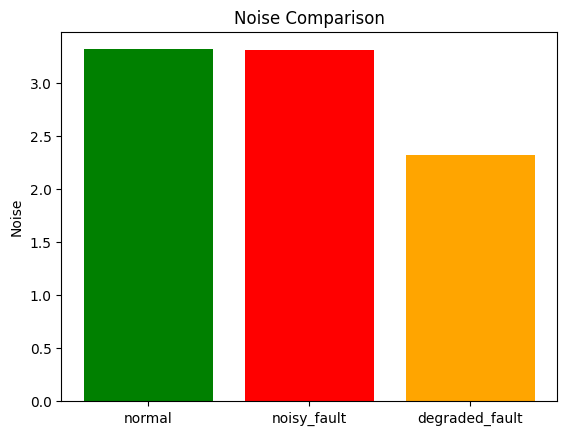

In [20]:
# 상태별 이름 지정
states = [
    'normal',
    'noisy_fault',
    'degraded_fault'
]

# 상태별 noise 값
noise_values = [
    normal_noise,
    noise_value,
    degraded_noise
]

# 막대그래프 생성
plt.bar(

    # x축 데이터
    states,

    # y축 데이터
    noise_values,

    # 상태별 색 지정
    color=['green', 'red', 'orange']
)

# 그래프 제목
plt.title("Noise Comparison")

# y축 이름
plt.ylabel("Noise")

# 그래프 출력
plt.show()

Dataset related to the publication "Low-Cost Three-Quadrant Single Solar Cell I-V Tracer" in Applied Sciences 2022, 12(13), 6623; https://doi.org/10.3390/app12136623
